# Precios, retornos y posterior Black-Litterman

Pipeline:

1. Universo desde `universo.py` (49 empresas, ranking col. AT, market caps col. F)
2. Precios diarios de yfinance con **corte 13-ago-2026** → ventana común a todos los tickers
3. Filtro de historia mínima: se excluyen tickers listados hace menos de `MIN_DIAS` días
   (SKHY y AUGO, exclusión definitiva)
4. Retornos diarios + covarianza Ledoit-Wolf (universo + SPY)
5. **Prior CAPM**: π_i = Rf + β_i·(ERM − Rf), con β_i = Cov(r_i, SPY)/Var(SPY).
   El ERM (col. V) es el CAGR esperado del SPY — el mercado es el SPY, no nuestro universo
6. **Views relativas**: cadena de pares adyacentes del ranking (P con +1/−1), paso
   `q = S/(n−1)` anualizado a diario, con Ω = diag((κ·q)²) vía `bl.py`
7. **Re-anclaje de nivel**: las views fijan diferencias; el nivel del posterior se ancla
   al equilibrio CAPM del universo (w'π), no al ERM
8. Sanity checks: monotonía, spread, nivel, tilt vs prior y sensibilidad a `S` y `κ`

> **Nota de diseño**: la incertidumbre de las views (Ω) se fija en forma directa y no vía
> Idzorek. Con Idzorek, Ω queda atado a la covarianza de mercado y el prior dominaba al
> ranking, degradando el posterior. Con Ω = (κ·q)² el ordenamiento del ranking se impone
> con holgura explícita, que es exactamente lo que el modelo quiere expresar:
> *cada empresa superará a la siguiente del ranking, nada más*.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from skfolio.moments import LedoitWolf
from skfolio.preprocessing import prices_to_returns

from bl import posterior_black_litterman
from universo import cargar_parametros_mercado, cargar_universo

pd.set_option("display.float_format", "{:.6f}".format)

# ---- Configuración ----
START = "2021-08-13"      # 5 años de historia solicitada; la ventana común la recorta el IPO más reciente
END = "2026-08-14"        # yfinance excluye `end` → incluye el 13-ago-2026 (corte definido)
MIN_DIAS = 500            # historia mínima requerida para entrar en la estimación
S_SPREAD = 0.08           # spread anual implícito en el ranking: rank 1 vs último
KAPPA = 0.5               # holgura de las views: error estándar = κ·q
TAU = 0.05                # peso del prior en BL
ANNUAL = 252              # días hábiles por año

universo = cargar_universo()
orden = universo["Ticker"].tolist()          # ya ordenado por Ranking (col. AT)
params = cargar_parametros_mercado()

print(f"Universo: {len(orden)} empresas")
print(f"ERM (col. V, CAGR esperado del SPY): {params['erm']:.4%}")
print(f"Rf (col. Y): {params['risk_free']:.4%}")
print(f"Primeras 5 del ranking: {orden[:5]}")

Universo: 49 empresas
ERM (col. V, CAGR esperado del SPY): 10.0000%
Rf (col. Y): 4.6300%
Primeras 5 del ranking: ['RDDT', 'RELY', 'NU', 'SEZL', 'NVDA']


In [2]:
# ---- Descarga de precios (cierre ajustado) ----
data = yf.download(
    orden + ["SPY"],
    start=START,
    end=END,
    auto_adjust=True,
    progress=False,
    threads=True,
)
closes = data["Close"][orden].copy()

# Historia disponible por ticker y filtro de historia mínima
dias = closes.notna().sum()
cortos = dias[dias < MIN_DIAS].index.tolist()
if cortos:
    detalle = universo.set_index("Ticker").loc[cortos, "Ranking"]
    print(f"⚠️ Excluidos por historia < {MIN_DIAS} días (rank AT):")
    for t in cortos:
        print(f"   {t}: {dias[t]} días (rank {detalle[t]}) | primer dato {closes[t].first_valid_index().date()}")

orden_f = [t for t in orden if t not in cortos]
closes = closes[orden_f].dropna()
print(f"\nUniverso efectivo: {len(orden_f)} empresas")
print(f"Ventana común: {closes.index[0].date()} → {closes.index[-1].date()} ({len(closes)} días)")

⚠️ Excluidos por historia < 500 días (rank AT):
   SKHY: 25 días (rank 14) | primer dato 2026-07-10
   AUGO: 272 días (rank 19) | primer dato 2025-07-16

Universo efectivo: 47 empresas
Ventana común: 2024-03-21 → 2026-08-13 (601 días)


La ventana común arranca en el IPO más reciente que supera el filtro (RDDT cotiza desde
marzo 2024), por eso se usan **retornos diarios**: con ~2.5 años de historia mensual
(≈30 obs) no habría muestra suficiente para una covarianza de ~47 activos.

In [3]:
# ---- Retornos, covarianza (universo + SPY) y betas ----
X = prices_to_returns(closes)          # retornos diarios simples, columnas = `orden_f`
orden_f = list(X.columns)
n = len(orden_f)

caps = universo.set_index("Ticker")["MarketCapUSD"].reindex(orden_f)
assert caps.notna().all(), "Hay market caps faltantes en el universo efectivo"
w_caps = (caps / caps.sum()).to_numpy()

# SPY alineado a la misma ventana (para las betas del prior CAPM)
spy_ret = data["Close"]["SPY"].reindex(closes.index).pct_change().iloc[1:]
X_full = pd.concat([X, spy_ret.rename("SPY")], axis=1).dropna()
assert list(X_full.columns) == orden_f + ["SPY"]

sigma_full = LedoitWolf().fit(X_full).covariance_
sigma = sigma_full[:n, :n]              # covarianza del universo (para BL y optimización)
cov_spy = sigma_full[:n, n]             # Cov(r_i, r_SPY)
var_spy = sigma_full[n, n]              # Var(r_SPY)
betas = pd.Series(cov_spy / var_spy, index=orden_f)

beta_u = float(betas @ w_caps)
print(f"X: {X.shape[0]} obs × {n} activos (ratio obs/activos: {X.shape[0]/n:.1f})")
print(f"Vol SPY: {np.sqrt(var_spy * ANNUAL):.2%} anual | β del universo (caps): {beta_u:.2f}")

X: 600 obs × 47 activos (ratio obs/activos: 12.8)
Vol SPY: 19.85% anual | β del universo (caps): 1.21


## Prior CAPM: el mercado es el SPY

El ERM (col. V) es el **CAGR esperado del SPY**, nada más. Los activos del universo se
pricedean contra el SPY con la Security Market Line — la misma construcción del Ke del
modelo Grinold-Kroner del Excel:

$$\pi_i = R_f + \beta_i\,(ERM - R_f), \qquad \beta_i = \frac{Cov(r_i, r_{SPY})}{Var(r_{SPY})}$$

- El SPY mismo tiene β = 1 → rinde el ERM. Un activo con β = 0 rinde la Rf.
- El universo cap-ponderado rinde Rf + β_u·(ERM − Rf) con β_u ≈ 2 (canasta concentrada,
  ~2× el riesgo del mercado): **más** que el ERM, no igual — no se lo fuerza al ERM.
- Todo en frecuencia diaria dentro del modelo (÷252), anualizado solo al reportar.

In [4]:
rf_diario = params["risk_free"] / ANNUAL
prem_diario = (params["erm"] - params["risk_free"]) / ANNUAL
pi_diario = rf_diario + betas.to_numpy() * prem_diario

mu_prior = pd.Series(pi_diario * ANNUAL, index=orden_f)
w_pi = float(mu_prior @ w_caps)
print(f"β: mín {betas.min():.2f} ({betas.idxmin()}) | máx {betas.max():.2f} ({betas.idxmax()})")
print(f"Prior π anual: mín {mu_prior.min():.4%} ({mu_prior.idxmin()}) | máx {mu_prior.max():.4%} ({mu_prior.idxmax()})")
print(f"Nivel de equilibrio CAPM del universo (w'π): {w_pi:.4%} anual")
mu_prior.head(5)

β: mín 0.24 (RSSS) | máx 1.82 (SEZL)
Prior π anual: mín 5.8961% (RSSS) | máx 14.4082% (SEZL)
Nivel de equilibrio CAPM del universo (w'π): 11.1491% anual


RDDT   0.114573
RELY   0.077515
NU     0.091369
SEZL   0.144082
NVDA   0.114933
dtype: float64

## Views relativas: cadena de pares adyacentes

El único insumo es el ranking de la columna AT (sobre el universo efectivo). Cada empresa `i`
superará a la `i+1` por el mismo paso `q`, con holgura `κ·q`:

- `q_anual = S / (n−1)`, expresado en frecuencia diaria (`/252`) para coincidir con `X`
- Por linealidad del posterior de BL, el rank 1 supera al último por ≈ `S` anual

In [5]:
from bl import matriz_picking

q_diario = (S_SPREAD / (n - 1)) / ANNUAL
Q = np.full(n - 1, q_diario)
P = matriz_picking(n)

mu_bl, sigma_bl = posterior_black_litterman(sigma, pi_diario, Q, tau=TAU, kappa=KAPPA)
mu_bl_annual = pd.Series(mu_bl * ANNUAL, index=orden_f)
print(f"Views: {len(Q)} | paso q: {q_diario * ANNUAL:.4%} anual por posición | κ = {KAPPA}")

Views: 46 | paso q: 0.1739% anual por posición | κ = 0.5


## Re-anclaje de nivel

Las views solo restringen *diferencias* de retornos: definen la forma de la escalera, no su
nivel. La proyección Σ-ponderada del posterior arrastra el nivel del prior, así que se
re-ancla explícitamente al **equilibrio CAPM del universo** (`w'π`): las views reordenan el
cross-section, pero el nivel agregado del universo se mantiene en lo que implica su riesgo
frente al SPY. Es un shift constante: no altera monotonía, ni spread, ni covarianza.

In [6]:
shift = w_pi - float(mu_bl_annual @ w_caps)
mu_post = mu_bl_annual + shift

print(f"Nivel pre-shift: {float(mu_bl_annual @ w_caps):.4%} | shift: {shift:+.4%} | nivel final: {float(mu_post @ w_caps):.4%}")
mu_post.head(5)

Nivel pre-shift: 7.3668% | shift: +3.7824% | nivel final: 11.1491%


RDDT   0.138634
RELY   0.136895
NU     0.135156
SEZL   0.133416
NVDA   0.131677
dtype: float64

## Sanity checks

In [7]:
# 1) Monotonía: el posterior debe ser no-creciente a lo largo del ranking
dif = np.diff(mu_post.values)
print(f"Monotonía: {bool(dif.max() <= 1e-6)} | mayor incremento entre posiciones: {dif.max():.2e} anual")

# 2) Spread efectivo top vs bottom (objetivo ≈ S)
print(f"Spread rank1 − último: {mu_post.iloc[0] - mu_post.iloc[-1]:.4%} anual (objetivo S={S_SPREAD:.0%})")

# 3) Nivel: equilibrio CAPM del universo (NO el ERM, que es del SPY)
print(f"Nivel cap-ponderado: {float(mu_post @ w_caps):.4%} = w'π = Rf + β_u(ERM − Rf) = {params['risk_free']:.4%} + {beta_u:.2f}×{(params['erm'] - params['risk_free']):.4%}")
print(f"Nivel equal-weight: {mu_post.mean():.4%} anual")

# 4) Tilt vs prior: el ranking reordena el cross-section del equilibrio
tilt = mu_post - mu_prior
print(f"Tilt anual vs prior: media {tilt.mean():.4%} | máx {tilt.max():.4%} ({tilt.idxmax()}) | mín {tilt.min():.4%} ({tilt.idxmin()})")

# 5) La covarianza posterior apenas cambia (views fuertes ⇒ M chica)
cambio_sigma = np.linalg.norm(sigma_bl - sigma) / np.linalg.norm(sigma)
print(f"Covarianza: ||Σ_BL − Σ||/||Σ|| = {cambio_sigma:.2e}")

Monotonía: True | mayor incremento entre posiciones: -1.74e-03 anual
Spread rank1 − último: 7.9996% anual (objetivo S=8%)
Nivel cap-ponderado: 11.1491% = w'π = Rf + β_u(ERM − Rf) = 4.6300% + 1.21×5.3700%
Nivel equal-weight: 9.8636% anual
Tilt anual vs prior: media 0.1804% | máx 6.9238% (RSSS) | mín -7.5495% (CRDO)
Covarianza: ||Σ_BL − Σ||/||Σ|| = 9.53e-03


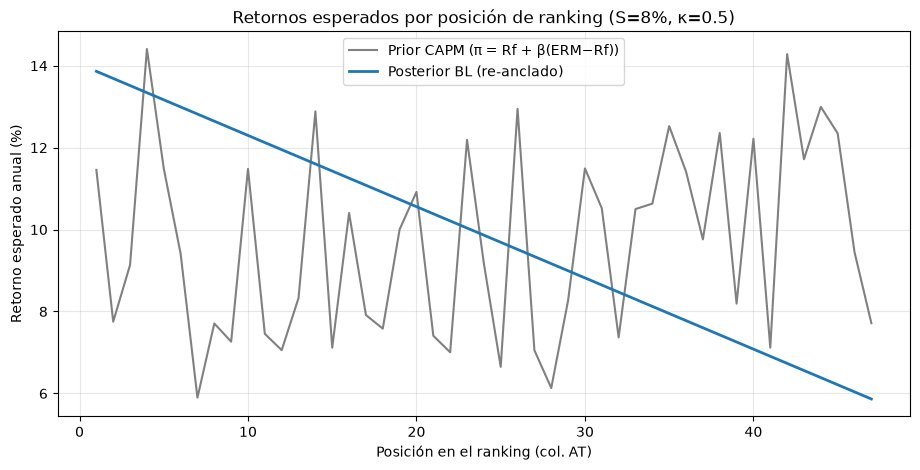

In [8]:
# Gráfico: prior vs posterior por posición de ranking
fig, ax = plt.subplots(figsize=(11, 5))
x_pos = np.arange(1, n + 1)
ax.plot(x_pos, mu_prior.values * 100, label="Prior CAPM (π = Rf + β(ERM−Rf))", color="gray", lw=1.5)
ax.plot(x_pos, mu_post.values * 100, label="Posterior BL (re-anclado)", color="tab:blue", lw=2)
ax.set_title(f"Retornos esperados por posición de ranking (S={S_SPREAD:.0%}, κ={KAPPA})")
ax.set_xlabel("Posición en el ranking (col. AT)")
ax.set_ylabel("Retorno esperado anual (%)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Sensibilidad a S (spread) y κ (holgura)

- `S` escala el spread total de la escalera (lineal).
- `κ` controla cuánta estructura del prior sobrevive a las views: con κ pequeño el
  ranking manda; con κ grande el posterior se relaja hacia el prior.
- La monotonía debe mantenerse en toda la grilla.

In [9]:
grilla_S = [0.04, 0.08, 0.12]
grilla_kappa = [0.25, 0.5, 1.0, 2.0]

filas = []
for s_ in grilla_S:
    for k_ in grilla_kappa:
        q_ = np.full(n - 1, (s_ / (n - 1)) / ANNUAL)
        mu_, sig_ = posterior_black_litterman(sigma, pi_diario, q_, tau=TAU, kappa=k_)
        mu_a = pd.Series(mu_ * ANNUAL, index=orden_f)
        viol_ = np.diff(mu_a.values).max()
        filas.append(
            {
                "S": s_,
                "kappa": k_,
                "spread_top_bottom": mu_a.iloc[0] - mu_a.iloc[-1],
                "max_tilt": (mu_a - mu_prior).abs().max(),
                "max_incremento": viol_,
            }
        )

sens = pd.DataFrame(filas)
print("Spread rank1 − último (anual):")
print(sens.pivot(index="S", columns="kappa", values="spread_top_bottom").map("{:.4%}".format))
print("\nMáximo |tilt| vs prior (anual):")
print(sens.pivot(index="S", columns="kappa", values="max_tilt").map("{:.4%}".format))
print("\nMayor incremento entre posiciones (anual; ≤0 ⇒ monotonía):")
print(sens.pivot(index="S", columns="kappa", values="max_incremento").map("{:.2e}".format))
print("\nMonotonía en toda la grilla:", bool((sens["max_incremento"] <= 1e-6).all()))

Spread rank1 − último (anual):
kappa     0.250000  0.500000  1.000000  2.000000
S                                               
0.040000   4.0000%   3.9999%   3.9998%   3.9992%
0.080000   7.9999%   7.9996%   7.9984%   7.9935%
0.120000  11.9997%  11.9986%  11.9946%  11.9782%

Máximo |tilt| vs prior (anual):
kappa     0.250000  0.500000  1.000000  2.000000
S                                               
0.040000   9.5720%   9.5719%   9.5719%   9.5715%
0.080000  11.3320%  11.3319%  11.3312%  11.3284%
0.120000  13.0920%  13.0915%  13.0891%  13.0799%

Mayor incremento entre posiciones (anual; ≤0 ⇒ monotonía):
kappa      0.250000   0.500000   1.000000   2.000000
S                                                   
0.040000  -8.70e-04  -8.70e-04  -8.69e-04  -8.69e-04
0.080000  -1.74e-03  -1.74e-03  -1.74e-03  -1.74e-03
0.120000  -2.61e-03  -2.61e-03  -2.61e-03  -2.60e-03

Monotonía en toda la grilla: True


## Conclusiones y siguiente paso

- El posterior BL queda ordenado monótonamente según el ranking AT, con spread total ≈ `S`
  y nivel re-anclado al equilibrio CAPM del universo (w'π).
- El ERM (col. V, 10%) es el CAGR esperado del SPY: entra al prior vía la SML
  (π_i = Rf + β_i(ERM − Rf)), igual que en el Ke del modelo Grinold-Kroner del Excel.
- El universo cap-ponderado (β_u ≈ 2) tiene un equilibrio **mayor** al ERM por su riesgo;
  no se lo fuerza al 10%.
- Parámetros base: `S = 8%` anual, `κ = 0.5`, `τ = 0.05`.
- SKHY (25 días de historia) y AUGO (272) se excluyen de la estimación por historia
  insuficiente (decisión definida).
- `bl.PriorBlackLitterman` entrega este posterior (mu re-anclado + Σ_BL) a los optimizadores
  de skfolio.

**Siguiente paso** → `03_optimizacion.ipynb`: optimización con `MeanRisk` (max Sharpe / min
varianza) usando el prior BL, constraints por grupos según las bandas de la tab `cliente`
y escritura de pesos en la col. AU (`Peso en Cartera`).